<a href="https://colab.research.google.com/github/calelo3232/Data-Cleaning/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/heresjohnnyv/congress-investments

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
import warnings
from datetime import datetime
from hmmlearn import hmm
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.simplefilter(action='ignore', category=FutureWarning)
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
data = pd.read_csv("SenatorCleaned.csv")

# List asset types
asset_types = data["Asset.Type"].unique()
print("There are {} different asset types in the dataset".format(len(asset_types)))
for i in range(len(asset_types)):
    print(asset_types[i])
print()

# List asset names
asset_names = data["Asset.Name"].unique()
print("There are {} different asset names in the dataset".format(len(asset_names)))

# List the top 10 asset names
asset_names_counts = data["Asset.Name"].value_counts()
for i in range(10):
    print("{}: {}".format(asset_names_counts.index[i],asset_names_counts[i]))

There are 10 different asset types in the dataset
Stock
Corporate Bond
Non-Public Stock
Other Securities
Municipal Security
Stock Option
Commodities/Futures Contract
Cryptocurrency
nan
Bond

There are 3404 different asset names in the dataset
The Priceline Group Inc. (NASDAQ): 186
Apple Inc.: 154
Pfizer Inc.: 109
Apple Inc. (NASDAQ): 93
Microsoft Corporation: 85
Bank of America Corporation: 82
AT&T Inc.: 78
General Electric Company: 73
Caesars Entertainment Corporation: 71
FireEye, Inc.: 70


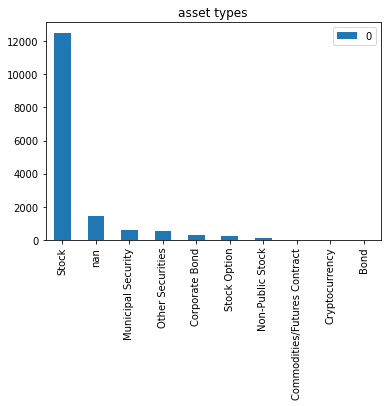

In [ ]:
counts = Counter(data['Asset.Type'])
top = dict(counts.most_common(20))
df = pd.DataFrame.from_dict(top, orient='index')
df.plot(kind='bar')
plt.title('asset types')
plt.show()

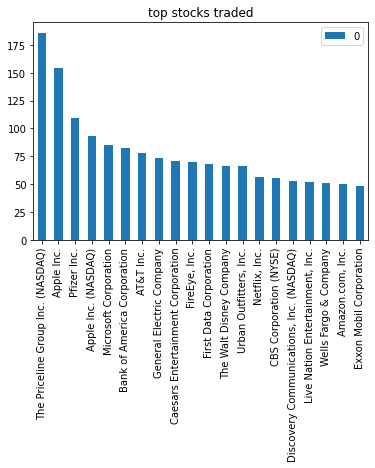

In [ ]:
counts = Counter(data['Asset.Name'])
top = dict(counts.most_common(20))
df = pd.DataFrame.from_dict(top, orient='index')
df.plot(kind='bar')
plt.title('top stocks traded')
plt.show()

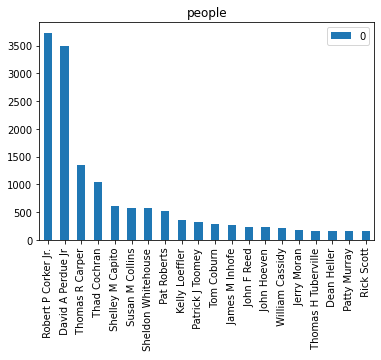

In [ ]:
counts = Counter(data['Name'])
top = dict(counts.most_common(20))
df = pd.DataFrame.from_dict(top, orient='index')
df.plot(kind='bar')
plt.title('people')
plt.show()

##Clustering

In [ ]:
senators_party = {
    'Jerry Moran': 'Republican',
    'John W Hickenlooper': 'Democrat',
    'Kelly Loeffler': 'Republican',
    'Pat Roberts': 'Republican',
    'Rick Scott': 'Republican',
    'Roger W Marshall': 'Republican',
    'Ron Johnson': 'Republican',
    'Thomas H Tuberville': 'Republican',
    'Thomas R Carper': 'Democrat',
    'William Cassidy': 'Republican',
    'William F Hagerty IV': 'Republican',
    'Chris Van Hollen': 'Democrat',
    'Christopher A Coons': 'Democrat',
    'Daniel S Sullivan': 'Republican',
    'Gary C Peters': 'Democrat',
    'John A Barrasso': 'Republican',
    'Joseph S Donnelly': 'Democrat',
    'Michael F Bennet': 'Democrat',
    'Robert P Corker Jr.': 'Republican',
    'A. Mitchell McConnell Jr.': 'Republican',
    'Dean Heller': 'Republican',
    'Jacklyn S Rosen': 'Democrat',
    'James M Inhofe': 'Republican',
    'John Cornyn': 'Republican',
    'John F Reed': 'Democrat',
    'Jon Kyl': 'Republican',
    'Ladda Tammy Duckworth': 'Democrat',
    'Mark R Warner': 'Democrat',
    'Patty Murray': 'Democrat',
    'Robert J Portman': 'Republican',
    'Robert P Casey Jr.': 'Democrat',
    'Shelley M Capito': 'Republican',
    'Steve Daines': 'Republican',
    'Thomas Udall': 'Democrat',
    'Timothy M Kaine': 'Democrat',
    'Tina Smith': 'Democrat',
    'Angus S King Jr.': 'Independent',
    'Barbara A Mikulski': 'Democrat',
    'Benjamin L Cardin': 'Democrat',
    'Cory A Booker': 'Democrat',
    'Daniel R Coats': 'Republican',
    'David A Perdue Jr': 'Republican',
    'David B Vitter': 'Republican',
    'Harry Reid': 'Democrat',
    'Jefferson B Sessions III': 'Republican',
    'Jeffry L Flake': 'Republican',
    'John D Rockefeller IV': 'Democrat',
    'John Hoeven': 'Republican',
    'John McCain': 'Republican',
    'Lamar Alexander': 'Republican',
    'Maria Cantwell': 'Democrat',
    'Mark Begich': 'Democrat',
    'Mark E Udall': 'Democrat',
    'Michael B Enzi': 'Republican',
    'Mike Rounds': 'Republican',
    'Patrick J Toomey': 'Republican',
    'Rafael E Cruz': 'Republican',
    'Roy Blunt': 'Republican',
    'Saxby Chambliss': 'Republican',
    'Sheldon Whitehouse': 'Democrat',
    'Susan M Collins': 'Republican',
    'Thad Cochran': 'Republican',
    'Thomas R Tillis': 'Republican',
    'Tom Coburn': 'Republican'
}

In [ ]:
df = pd.read_csv('SenatorCleaned.csv')

#handle names and political parties
df['Name'] = df['Name'].str.strip()
df['party'] = df['Name'].map(senators_party)

#handle dates
df['Transaction.Date'] = pd.to_datetime(df['Transaction.Date'])
df = df.sort_values(by='Transaction.Date')
df['Days_from_earliest_date'] = (df['Transaction.Date'] - df['Transaction.Date'].min()).dt.days
df = df.drop(columns=['Transaction.Date']).rename(columns={'Days_from_earliest_date': 'Transaction.Date'})

In [ ]:
#preprocess the data
#df = df[['Name', 'Asset.Name', 'Transaction.Date', 'Type']]
#specifically get sales
df = df[df['Type'].str.startswith('Sale')]

#encode the Asset.Name and Owner columns
le_asset = LabelEncoder()
df['Asset.Name'] = le_asset.fit_transform(df['Asset.Name'])
le_owner = LabelEncoder()
df['Name'] = le_owner.fit_transform(df['Name'])

#create the observation sequences
sequences = []
for owner, group in df.groupby('Name'):
    sequences.append(group[['Asset.Name', 'Transaction.Date']].values)

#train the HMM
n_clusters = 3
model = hmm.GaussianHMM(n_components=n_clusters, covariance_type='diag', n_iter=100)
X = np.concatenate(sequences)
lengths = [len(seq) for seq in sequences]
model.fit(X, lengths)

#predict the hidden states for each sequence
hidden_states = []
for seq in sequences:
    hidden_states.append(model.predict(seq))

#assign clusters to individuals
clusters = []
for hs in hidden_states:
    clusters.append(np.argmax(np.bincount(hs)))

owner_clusters = pd.DataFrame({'Name': le_owner.inverse_transform(np.unique(df['Name'])),
                               'Cluster': clusters})


<ipython-input-84-ba4259d40b81>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Asset.Name'] = le_asset.fit_transform(df['Asset.Name'])
<ipython-input-84-ba4259d40b81>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Name'] = le_owner.fit_transform(df['Name'])


In [ ]:
for i in range(n_clusters):
    print(f"Cluster {i}:")
    print(owner_clusters[owner_clusters['Cluster'] == i]['Name'].tolist())
    print()

Cluster 0:
['Barbara A Mikulski', 'Benjamin L Cardin', 'Daniel R Coats', 'David B Vitter', 'Harry Reid', 'John D Rockefeller IV', 'Maria Cantwell', 'Mark E Udall', 'Robert P Corker Jr.', 'Saxby Chambliss', 'Susan M Collins', 'Thomas R Tillis', 'Tom Coburn']

Cluster 1:
['A. Mitchell McConnell Jr.', 'Angus S King Jr.', 'Chris Van Hollen', 'Christopher A Coons', 'Daniel S Sullivan', 'David A Perdue Jr', 'Dean Heller', 'Gary C Peters', 'Jacklyn S Rosen', 'James M Inhofe', 'Jerry Moran', 'John A Barrasso', 'John Cornyn', 'John F Reed', 'John Hoeven', 'John McCain', 'John W Hickenlooper', 'Jon Kyl', 'Joseph S Donnelly', 'Kelly Loeffler', 'Ladda Tammy Duckworth', 'Lamar Alexander', 'Mark R Warner', 'Michael B Enzi', 'Michael F Bennet', 'Pat Roberts', 'Patrick J Toomey', 'Patty Murray', 'Rafael E Cruz', 'Rick Scott', 'Robert J Portman', 'Robert P Casey Jr.', 'Roger W Marshall', 'Ron Johnson', 'Roy Blunt', 'Sheldon Whitehouse', 'Shelley M Capito', 'Steve Daines', 'Thad Cochran', 'Thomas H Tube

In [ ]:
for i in range(n_clusters):
    print(f"Cluster {i}:")
    parties = [senators_party[name] for name in owner_clusters[owner_clusters['Cluster'] == i]['Name'].tolist()]
    print(parties)
    print('Republican: ', parties.count('Republican'))
    print('Democrat: ', parties.count('Democrat'))
    print('Independent: ', parties.count('Independent'))
    print()

Cluster 0:
['Democrat', 'Democrat', 'Republican', 'Republican', 'Democrat', 'Democrat', 'Democrat', 'Democrat', 'Republican', 'Republican', 'Republican', 'Republican', 'Republican']
Republican:  7
Democrat:  6
Independent:  0

Cluster 1:
['Republican', 'Independent', 'Democrat', 'Democrat', 'Republican', 'Republican', 'Republican', 'Democrat', 'Democrat', 'Republican', 'Republican', 'Republican', 'Republican', 'Democrat', 'Republican', 'Republican', 'Democrat', 'Republican', 'Democrat', 'Republican', 'Democrat', 'Republican', 'Democrat', 'Republican', 'Democrat', 'Republican', 'Republican', 'Democrat', 'Republican', 'Republican', 'Republican', 'Democrat', 'Republican', 'Republican', 'Republican', 'Democrat', 'Republican', 'Republican', 'Republican', 'Republican', 'Democrat', 'Democrat', 'Democrat', 'Democrat', 'Republican', 'Republican']
Republican:  28
Democrat:  17
Independent:  1

Cluster 2:
['Democrat', 'Republican', 'Republican', 'Democrat', 'Republican']
Republican:  3
Democrat: 

In [ ]:
df = pd.read_csv('SenatorCleaned.csv')

#handle names and political parties
df['Name'] = df['Name'].str.strip()
df['party'] = df['Name'].map(senators_party)

#handle dates
df['Transaction.Date'] = pd.to_datetime(df['Transaction.Date'])
df = df.sort_values(by='Transaction.Date')
df = df[df['Transaction.Date'] > "2014-01-01"]

#split on sale and purchase
df_sale = df[df['Type'].str.startswith('Sale')]
df_pur = df[df['Type'].str.startswith('Purchase')]

#encode the Asset.Name and Owner columns
le_asset1 = LabelEncoder()
df_sale['Asset.Name'] = le_asset1.fit_transform(df_sale['Asset.Name'])
le_owner1 = LabelEncoder()
df_sale['Name'] = le_owner1.fit_transform(df_sale['Name'])

le_asset2 = LabelEncoder()
df_pur['Asset.Name'] = le_asset2.fit_transform(df_pur['Asset.Name'])
le_owner2 = LabelEncoder()
df_pur['Name'] = le_owner2.fit_transform(df_pur['Name'])

#examine only Asset.Name and dates for decomposition
newdf_sale = df_sale[['Asset.Name', 'Transaction.Date']]
newdf_sale = newdf_sale.set_index('Transaction.Date')
newdf_pur = df_pur[['Asset.Name', 'Transaction.Date']]
newdf_pur = newdf_pur.set_index('Transaction.Date')

<ipython-input-9-581b2b8ed6c3>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sale['Asset.Name'] = le_asset1.fit_transform(df_sale['Asset.Name'])
<ipython-input-9-581b2b8ed6c3>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sale['Name'] = le_owner1.fit_transform(df_sale['Name'])
<ipython-input-9-581b2b8ed6c3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

<Figure size 640x480 with 0 Axes>

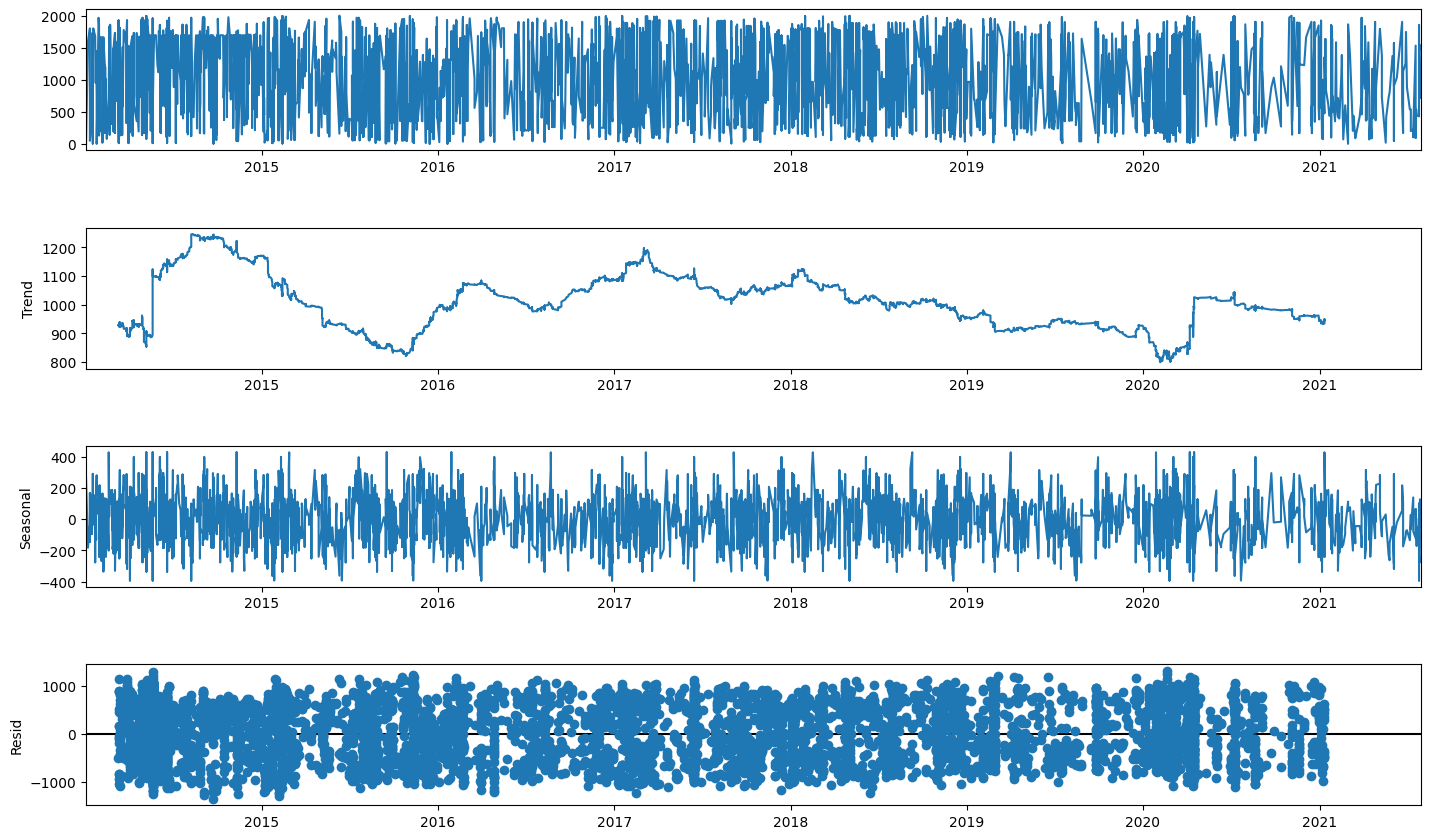

In [ ]:
result = seasonal_decompose(newdf_sale, period=365) # decompose seasonal sale trend with 365 day cycle
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16, 9)

<Figure size 640x480 with 0 Axes>

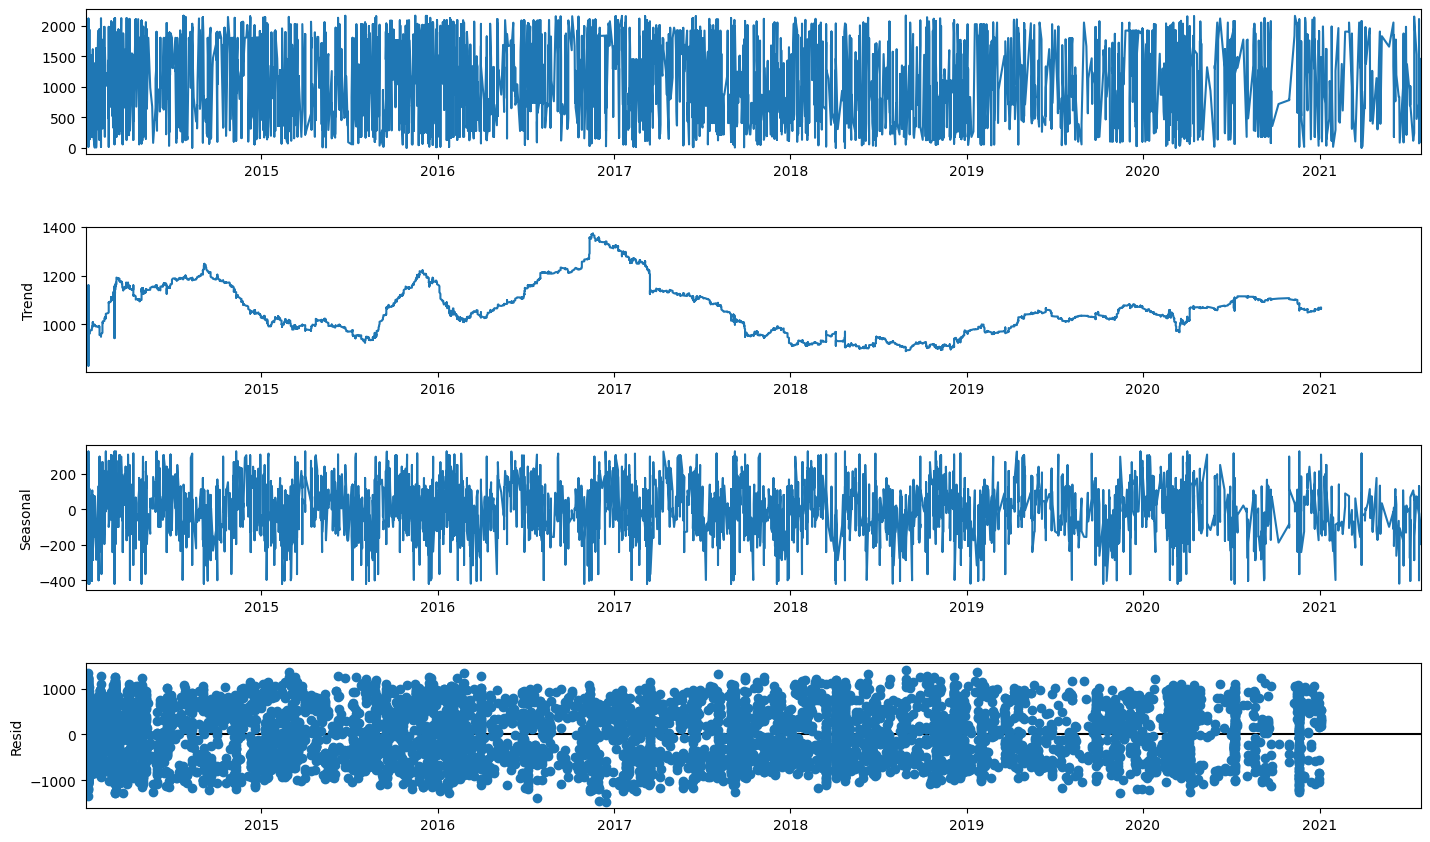

In [ ]:
result = seasonal_decompose(newdf_pur, period=365) # decompose seasonal purchase trend with 365 day cycle
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16, 9)

/usr/local/lib/python3.9/dist-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


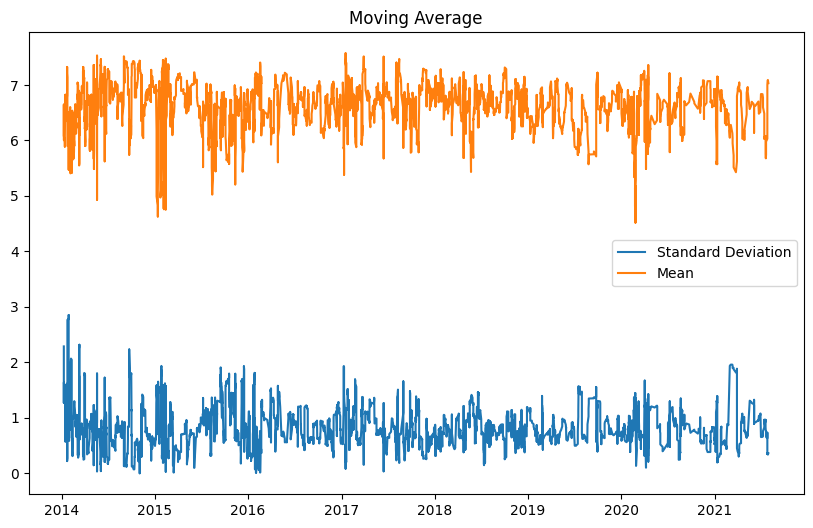

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
df_logsale = np.log(newdf_sale) # convert dataframe to log values for easier comprehension
df_logsale.replace([np.inf, -np.inf], 0, inplace=True) # replace infinity values with 0
moving_avg = df_logsale.rolling(12).mean() # compute rolling averages by year
std_dev = df_logsale.rolling(12).std()
plt.title('Moving Average')
plt.plot(std_dev, label = "Standard Deviation")
plt.plot(moving_avg, label = "Mean")
plt.legend()
plt.show()

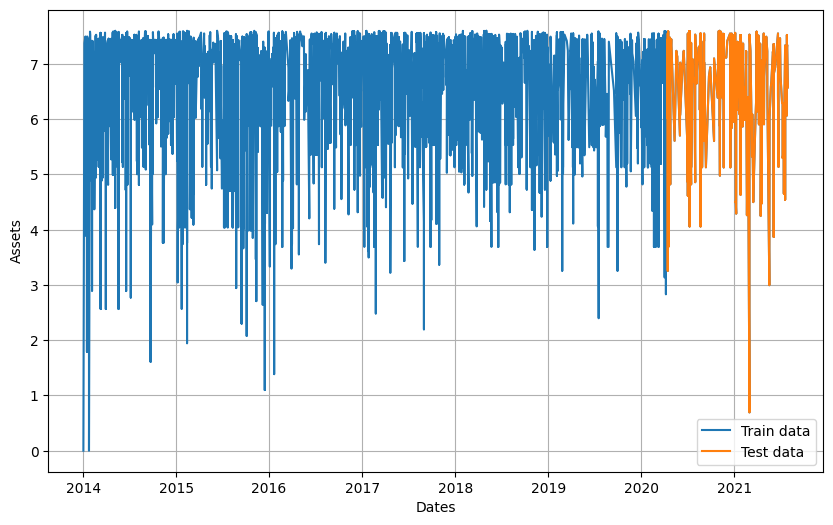

In [ ]:
#split data into train and training set
train_sale, test_sale = df_logsale[3:int(len(df_logsale)*0.9)], df_logsale[int(len(df_logsale)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Assets')
plt.plot(df_logsale, label='Train data')
plt.plot(test_sale, label='Test data')
plt.legend()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=43105.201, Time=0.23 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=20106.967, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=36094.094, Time=1.32 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.55 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=17394.381, Time=1.46 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=17247.729, Time=2.55 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=5.68 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=4.66 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=17291.297, Time=0.93 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.52 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=17151.984, Time=6.05 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=7.92 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=6.68 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=17084.266, Time=14.84 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=17098.055, T

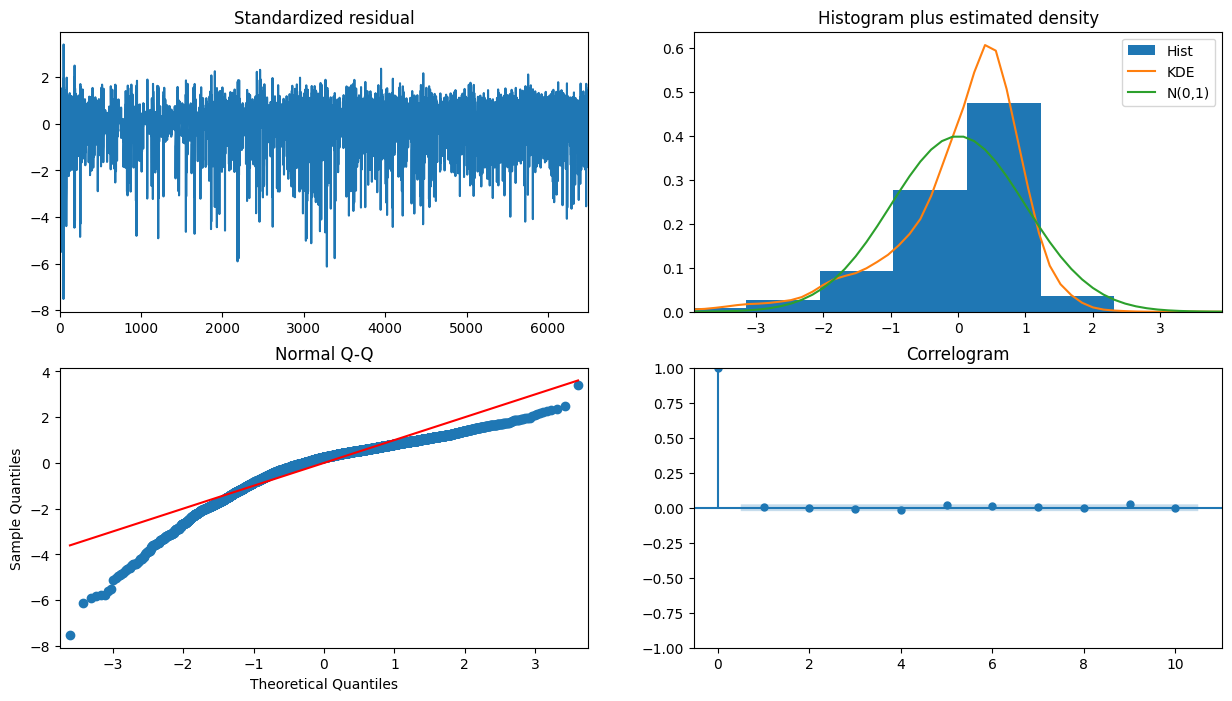

In [ ]:
model_autoARIMA = auto_arima(train_sale, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # no Seasonality
                      start_P=0,
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [ ]:
# Build Model
model_sale = ARIMA(train_sale, order=(3,0,3))
fitted_sale = model_sale.fit()
print(fitted_sale.summary())

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Asset.Name   No. Observations:                 6496
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -8528.721
Date:                Sat, 01 Apr 2023   AIC                          17073.442
Time:                        23:02:12   BIC                          17127.673
Sample:                             0   HQIC                         17092.199
                               - 6496                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6083      0.036    181.933      0.000       6.537       6.680
ar.L1          0.4647      0.186      2.501      0.012       0.100       0.829
ar.L2          0.2002      0.229      0.876      0.3

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


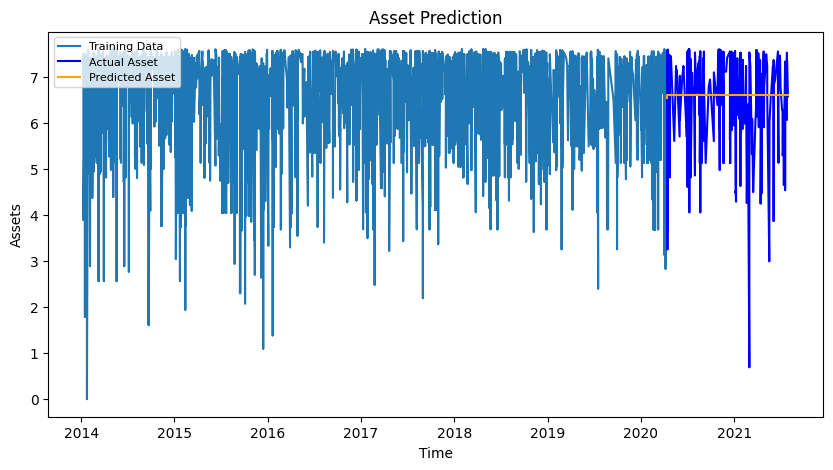

In [ ]:
# Forecast
forecast = fitted_sale.forecast(723, alpha=0.05)
forecast_series = pd.Series(np.array(forecast), index=test_sale.index)

# Plot
plt.figure(figsize=(10,5), dpi=100)
plt.plot(train_sale, label='Training Data')
plt.plot(test_sale, color = 'blue', label='Actual Asset')
plt.plot(forecast_series, color = 'orange',label='Predicted Asset')
plt.title('Asset Prediction')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.legend(loc='upper left', fontsize=8)
plt.show()